In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pandas.plotting import table
from PIL import Image

from xbbg import blp
from datetime import datetime, timedelta

from scipy.stats import percentileofscore

from datetime import datetime, timedelta
from pandas.tseries.offsets import DateOffset


import matplotlib.colors as mcolors
import numpy as np

In [2]:





def calculate_term_percentiles(ccys, normalize=True):
    tenors = ['1W', '2W', '1M', '2M', '3M', '6M', '1Y']
    spreads = [
        ('1W', '2W'),
        ('1W', '1M'),
        ('2W', '1M'),
        ('1W', '2W'),
        ('1W', '1M'),
        ('1M', '3M'),
        ('1M', '6M'),
        ('1M', '1Y'),
        ('3M', '6M'),
        ('3M', '1Y'),
        ('6M', '1Y')
        ]
    results = {}
    
    for ccy in ccys:
        end_date = datetime.now().strftime("%Y-%m-%d")
        start_date = (datetime.now() - timedelta(days=365 * 5)).strftime("%Y-%m-%d")
        df_vols = {}
        
        for tenor in tenors:
            ticker_IV = f"{ccy}V{tenor} BGN Curncy"
            data_IV = blp.bdh(
                tickers=ticker_IV,
                flds="PX_LAST",
                start_date=start_date,
                end_date=end_date)
            if not data_IV.empty:
                data_IV.columns = [tenor]
                df_vols[tenor] = data_IV
            else:
                print(f"No data for {ticker_IV}, skipping.")
        
        df_vols_all = pd.concat(df_vols.values(), axis=1)
        df_spreads = pd.DataFrame(index=df_vols_all.index)
        
        for spread in spreads:
            first_tenor, second_tenor = spread
            spread_name = f"{first_tenor}-{second_tenor}"
            
            if normalize:
                # Normalized spread: (short - long) / long
                # Expressed as percentage of the longer tenor vol
                df_spreads[spread_name] = (
                    (df_vols_all[first_tenor] - df_vols_all[second_tenor]) 
                    / df_vols_all[second_tenor]
                ) * 100  # multiply by 100 to express as percentage
            else:
                # Raw spread (original approach)
                df_spreads[spread_name] = df_vols_all[first_tenor] - df_vols_all[second_tenor]
        
        # Rest of your code stays the same...
        three_months_ago = (df_spreads.index[-1] - DateOffset(months=3)).date()
        one_year_ago = (df_spreads.index[-1] - DateOffset(years=1)).date()
        three_year_ago = (df_spreads.index[-1] - DateOffset(years=3)).date()
        
        df_spreads_3m = df_spreads[df_spreads.index >= three_months_ago]
        df_spreads_1Y = df_spreads[df_spreads.index >= one_year_ago]
        df_spreads_3Y = df_spreads[df_spreads.index >= three_year_ago]
        
        current_spread = df_spreads.iloc[-1]
        
        spread_data = {}
        for column in df_spreads.columns:
            actual_value = current_spread[column]
            percentiles_3M = np.sum(df_spreads_3m[column] < actual_value) / df_spreads_3m[column].count() * 100
            percentiles_1Y = np.sum(df_spreads_1Y[column] < actual_value) / df_spreads_1Y[column].count() * 100
            percentiles_3Y = np.sum(df_spreads_3Y[column] < actual_value) / df_spreads_3Y[column].count() * 100
            percentiles_5Y = np.sum(df_spreads[column] < actual_value) / df_spreads[column].count() * 100

            spread_data[column] = {
                'Spread/Long Tenor (%)': round(actual_value, 2),
                "3M Percentile": round(percentiles_3M, 2),
                "1Y Percentile": round(percentiles_1Y, 2),
                "3Y Percentile": round(percentiles_3Y, 2),
                "5Y Percentile": round(percentiles_5Y, 2)}
        
        results[ccy] = pd.DataFrame.from_dict(spread_data, orient="index")
    
    # Combine results...
    combined_df = []
    for ccy, df_summary in results.items():
        df_summary['CCY'] = ccy
        combined_df.append(df_summary)
    
    final_df = pd.concat(combined_df, axis=0)
    final_df.reset_index(inplace=True)
    final_df.rename(columns={'index': 'Spread'}, inplace=True)
    df = final_df[['CCY', 'Spread', 'Spread/Long Tenor (%)', '3M Percentile', '1Y Percentile', '3Y Percentile', '5Y Percentile']]
    
    # Group by CCY (in original order) and sort by 1Y Percentile within each group
    df['CCY'] = pd.Categorical(df['CCY'], categories=ccys, ordered=True)
    df = df.sort_values(by=['CCY', '1Y Percentile'], ascending=[True, False])
    df.reset_index(drop=True, inplace=True)
    
    return df

In [3]:
def plot_term_structure_table(df):
    # Add empty rows between CCY groups for visual separation
    ccys_in_order = df['CCY'].cat.categories.tolist()
    rows_to_plot = []
    
    for i, ccy in enumerate(ccys_in_order):
        ccy_data = df[df['CCY'] == ccy]
        for _, row in ccy_data.iterrows():
            rows_to_plot.append(row.tolist())
        # Add empty row after each group (except the last)
        if i < len(ccys_in_order) - 1:
            rows_to_plot.append([''] * len(df.columns))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, len(rows_to_plot) * 0.35 + 1))
    ax.axis('off')
    ax.axis('tight')
    
    # Create table
    table = ax.table(
        cellText=rows_to_plot,
        colLabels=df.columns.tolist(),
        cellLoc='center',
        loc='center')
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    
    # Color mapping for 1Y Percentile (red to green)
    cmap = plt.cm.RdYlGn
    norm = mcolors.Normalize(vmin=0, vmax=100)
    # Get column indices
    col_names = df.columns.tolist()
    ccy_col_idx = col_names.index('CCY')
    spread_col_idx = col_names.index('Spread')
    spread_long_col_idx = col_names.index('Spread/Long Tenor (%)')
    percentile_1y_col_idx = col_names.index('1Y Percentile')
    
    # Define grey shades for first 3 columns
    grey_colors = {
        ccy_col_idx: '#606060',           # Dark grey for CCY
        spread_col_idx: "#A09898",         # Medium grey for Spread
        spread_long_col_idx: '#b8b8b8'}     # Light grey for Spread/Long Tenor

    # Style header row
    for j, col in enumerate(df.columns):
        cell = table[(0, j)]
        cell.set_facecolor('#404040')
        cell.set_text_props(color='white', fontweight='bold')
    # Style data rows
    for i, row in enumerate(rows_to_plot):
        row_idx = i + 1  # +1 because row 0 is header
        # Check if empty row (separator)
        if row[0] == '':
            for j in range(len(df.columns)):
                cell = table[(row_idx, j)]
                cell.set_facecolor('white')
                cell.set_edgecolor('white')
        else:
            for j in range(len(df.columns)):
                cell = table[(row_idx, j)]
                cell.set_edgecolor('white')
                # Apply grey gradient to first 3 columns
                if j in grey_colors:
                    cell.set_facecolor(grey_colors[j])
                    # White text for darker backgrounds
                    if j == ccy_col_idx:
                        cell.set_text_props(color='white', fontweight='bold')
                    elif j == spread_col_idx:
                        cell.set_text_props(color='white')
                    else:
                        cell.set_text_props(color='black')
                # Color code the 1Y Percentile column
                elif j == percentile_1y_col_idx:
                    percentile_val = row[percentile_1y_col_idx]
                    color = cmap(norm(percentile_val))
                    cell.set_facecolor(color)
                    cell.set_text_props(color='black', fontweight='bold')
                # Default styling for other columns
                else:
                    cell.set_facecolor('#f8f8f8')
    plt.title('ATM Vol Term Structure Percentiles  \n \n Spread/Long Tenor (%) = (T1 - T2 / T2) * 100', 
              fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


In [4]:
ccys = ['USDJPY']

df = calculate_term_percentiles(ccys)

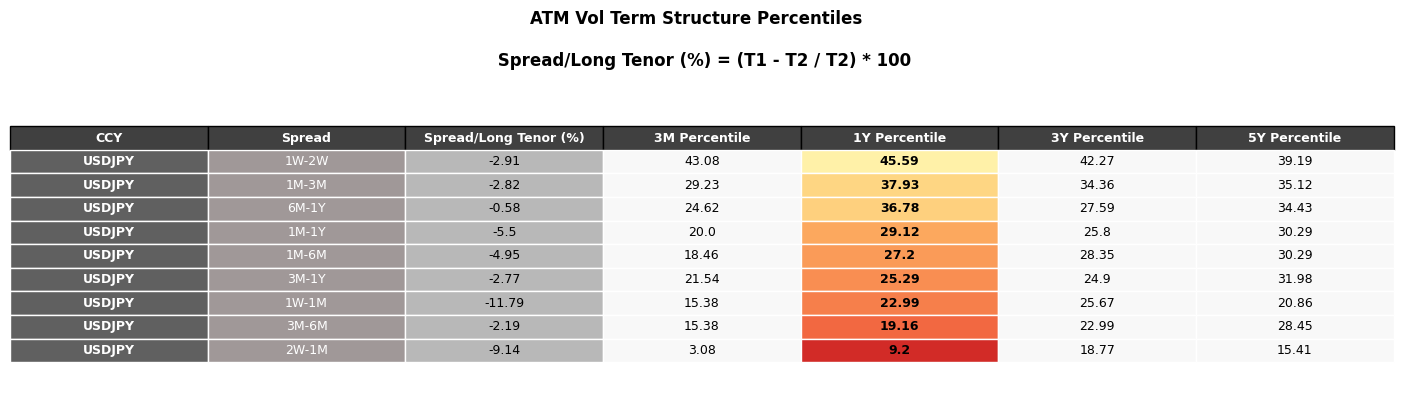

In [5]:
plot_term_structure_table(df)